<a href="https://colab.research.google.com/github/irenehavsa/mental-disorder-prevalence/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Project: Analysis of the Depression Trend Over Time in Indonesia
# Notebook: 01_eda.ipynb
# Author: Irene Havsa

In [3]:
# Import required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis

### 1. Import Data

The dataset used in this notebook is sourced from Kaggle. See here for more details: https://www.kaggle.com/datasets/thedevastator/uncover-global-trends-in-mental-health-disorder/data.

In [4]:
# Read the CSV
url = "https://raw.githubusercontent.com/irenehavsa/mental-disorder-prevalence/main/data/raw/mental_health_depression_disorder_data.csv"
df = pd.read_csv(url)
display(df.head())

/tmp/ipython-input-2561791384.py:3: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260


###Explore Original Data

In [ ]:
# See the number of rows and columns
df.shape

In [ ]:
# See list of columns and their data type
df.info()

# Note of result-1: the columns' naming convention are not standard. I'll modify them into snake_case and remove unnecessary symbols and words.
# Note of result-2: the original index column is not needed for analysis, thus should be removed.

In [ ]:
# See list of countries
df.Entity.unique()

# Note of result-1: There is an entity "World", which is the prevalance data of the whole countries combined. There is also "Southeast Asia", which should represent the prevalance of all SEA countries combined.
# Note of result-2: Timor separated from Indonesia in May 2002, therefore if there is prevalence data before that year, it is unreliable. Note that this data is synthethic and there could be parts that don't make sense.

In [ ]:
# See list of years
df.Year.unique()

# Note of result: there is data of the BCE years, which shouldn't be possible. I'll explore the data on the next step.

In [ ]:
# Explore data of various years and value of columns

# df.loc[(df['Year'] == '1000 BCE')]
# df.loc[(df['Year'] == '1990')]
# df.loc[(df['Depression (%)'].notnull())]
df.loc[(df['Year'] == '1990') & (df['Depression (%)'].notnull())]

# Note of result: only data with the year 1990 and later AND depression data not null is valid, therefore the other should be removed.

In [26]:
# See sample of complete data of a country
df.loc[(df['Entity'] == 'Indonesia') & (df['Depression (%)'].notnull())]

# Note of result: here it shows that there is data for Timor for the years before 2002. They are not valid since at those time Timor was still part of Indonesia. Thus, the data will be removed.

KeyError: 'Entity'

###2. Cleanse and Prepare Data

From the original data exploration above, here is what I'll do:
1.   Remove 'index' column
2.   Rename columns' name into snake_case and remove unnecessary symbols and words to make them compact
3.   Since the scope of the analysis is Southeast Asia (SEA), only include data with Entity includes SEA countries, "Southeast Asia", and "World"
4.   Only include data with the year 1990 or later and with 'depression' column not null.
5.   Exclude data of East Timor ("Timor") before the year 2002, since it is not valid   



In [ ]:
# Remove the original index column since it will not be used in this analysis
df = df.drop(columns=['index'])

# Rename columns' name
df.columns = ['entity', 'code', 'year', 'schizophrenia', 'bipolar', 'eating_disorder', 'anxiety', 'drug_use', 'depression', 'alcohol_use']

# Convert prevalence columns to numeric, coercing errors to NaN
prevalence_columns = ['schizophrenia', 'bipolar', 'eating_disorder', 'anxiety', 'drug_use', 'depression', 'alcohol_use']
for col in prevalence_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Include only relevant entities
entities_to_include = ['Southeast Asia', 'World', 'Indonesia', 'Timor', 'Malaysia', 'Singapore', 'Brunei', 'Philippines', 'Myanmar', 'Thailand', 'Laos', 'Cambodia']
df = df[df['entity'].isin(entities_to_include)]

# Include only valid data: year >= 1990 and 'depression' is not null
# First change the 'year' data type into numeric
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df[(df['year'] >= 1990) & (df['depression'].notnull())]

# Apply country-specific minimum year thresholds
df = df[(df['entity'] != 'Timor') | (df['year'] >= 2002)]

# Display the updated dataframe
display(df.head())

In [ ]:
# There should be 11*28 + 1*16 (for Timor) = 324 rows
df.shape

In [ ]:
# Review updated dataframe
# df.loc[(df['entity'] == 'Southeast Asia')]
df.loc[(df['entity'] == 'Thailand')]

In [15]:
# 'Unpivot' prevalence data
df = pd.melt(df, id_vars=['entity', 'code', 'year'], var_name='mental_disorder', value_name='prevalence')
df.head()

,entity,code,year,mental_disorder,prevalence
0,Brunei,BRN,1990.0,schizophrenia,0.274544
1,Brunei,BRN,1991.0,schizophrenia,0.273819
2,Brunei,BRN,1992.0,schizophrenia,0.273212
3,Brunei,BRN,1993.0,schizophrenia,0.272736
4,Brunei,BRN,1994.0,schizophrenia,0.272383


###3. Mental Disorders Trend Over Time

This section will the overview of the prevalence of various mental disorders.

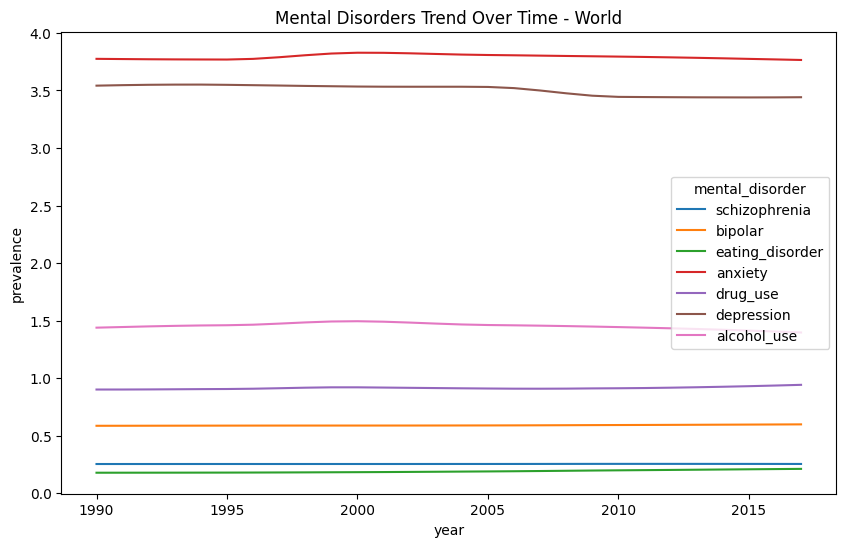

In [16]:
df_for_visual = df[df['entity'].isin(['World'])]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - World')
plt.show()

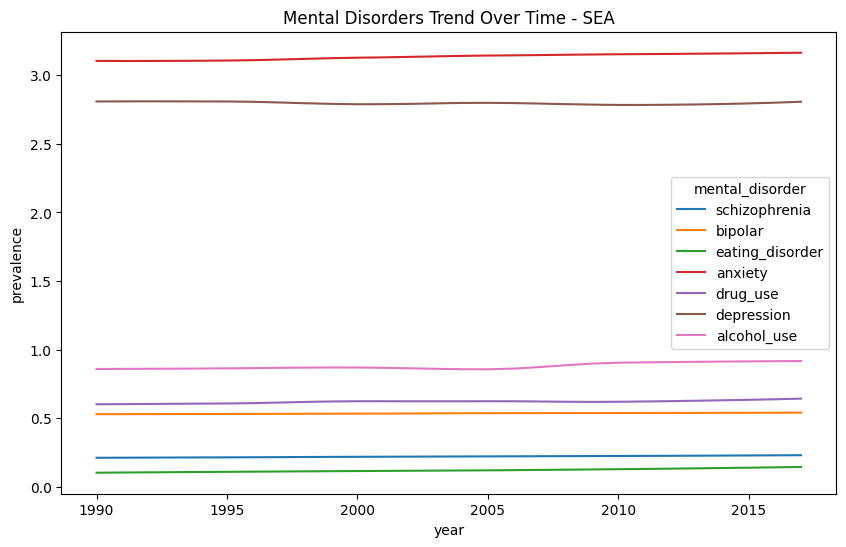

In [17]:
df_for_visual = df[df['entity'].isin(['Southeast Asia'])]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='mental_disorder')
plt.title('Mental Disorders Trend Over Time - SEA')
plt.show()

As you can see from the above line charts, there are no significant changes in the prevalence of each disorder over time, both around the world and within Southeast Asia. However, it could be caused by huge discrepancy between the prevalence of depression and anxiety compared to the other mental disorders. If we look only on depression and anxiety, we might see more fluctuation on the prevalence over time.

On another note, the prevalence of each disorder are less in SEA compared to the world.

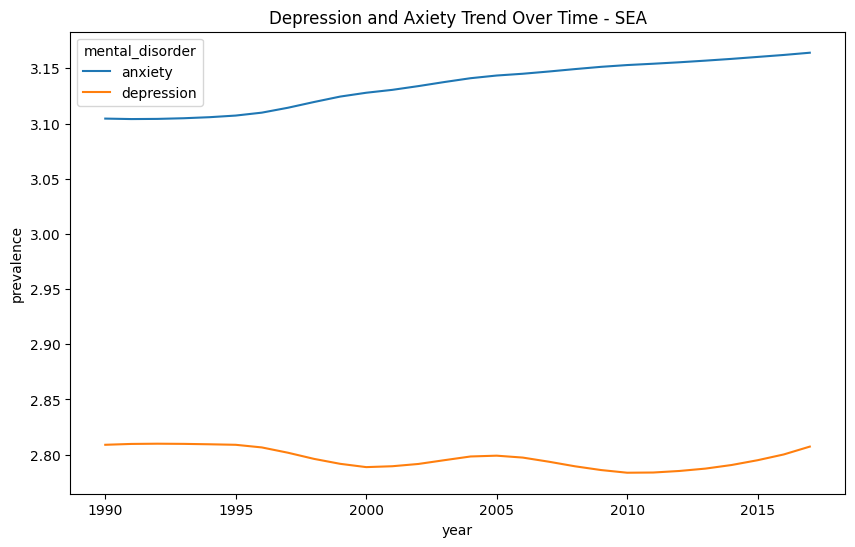

In [25]:
df_for_visual = df[(df['entity'].isin(['Southeast Asia'])) & (df['mental_disorder'].isin(['depression', 'anxiety']))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='mental_disorder')
plt.title('Depression and Axiety Trend Over Time - SEA')
plt.show()

As expected, when we include only depression and anciety, the changes on their line charts are more prominent.

###2. Depression Trend Over Time

This section will explore the prevalence of depression, starting from the prevalence of the whole world and drill down into the prevalence in Indonesia.

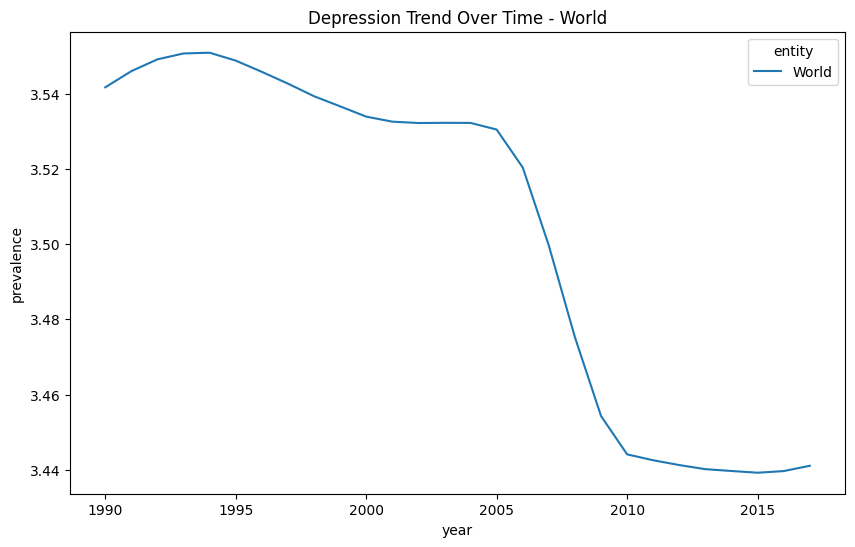

In [24]:
# Depression Trend
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'].isin(['World']))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time - World')
plt.show()


There is a sharp decline of the depression prevalence around the world between the year 2005 and 2010. Before that, there is also a modest declide between 1994 and 2000, which continued with a stable prevalence until 2005.

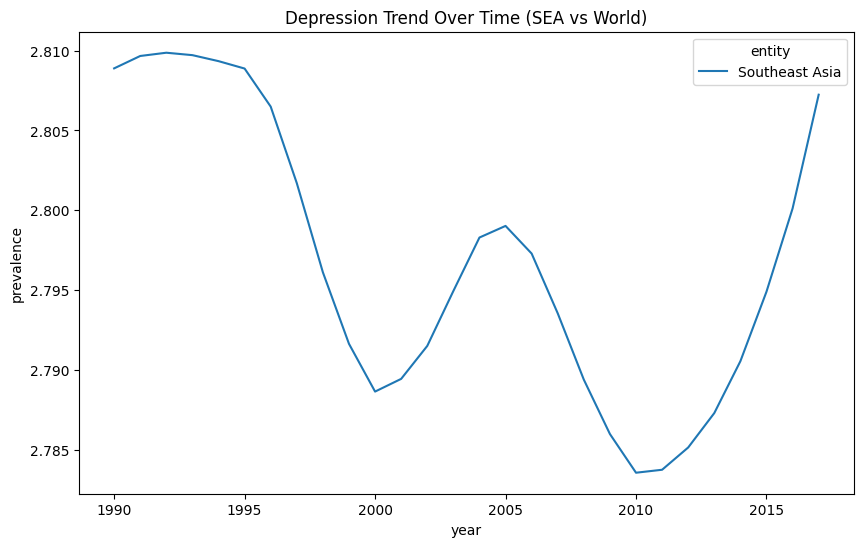

In [22]:
# Depression Trend
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'].isin(['Southeast Asia']))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time - SEA')
plt.show()


In Southeast Asia, the prevalence of depression is more fluctuative. Starting from a relatively stable prevalence from 1990 to 1995 at around 2.81%, it then took a sharp decline which ended at 2.79% in 2000. But it continue with significant increase until 2005 at around 2.80%, then another decrease until 2.785% in 2010. Then there is another increase until almost back to 2.81% in 2017.

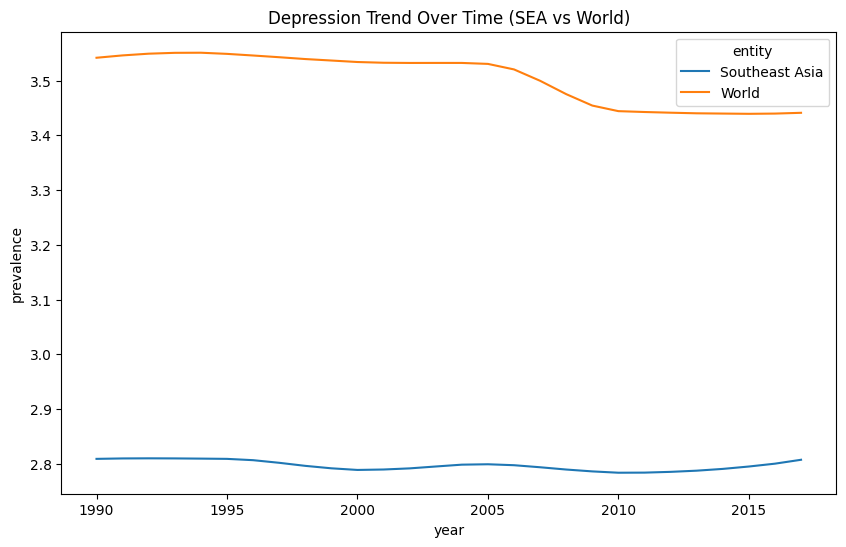

In [23]:
# Depression Trend
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'].isin(['Southeast Asia', 'World']))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time (SEA vs World)')
plt.show()


Above is the comparison of depression prevalence between SEA and the World.

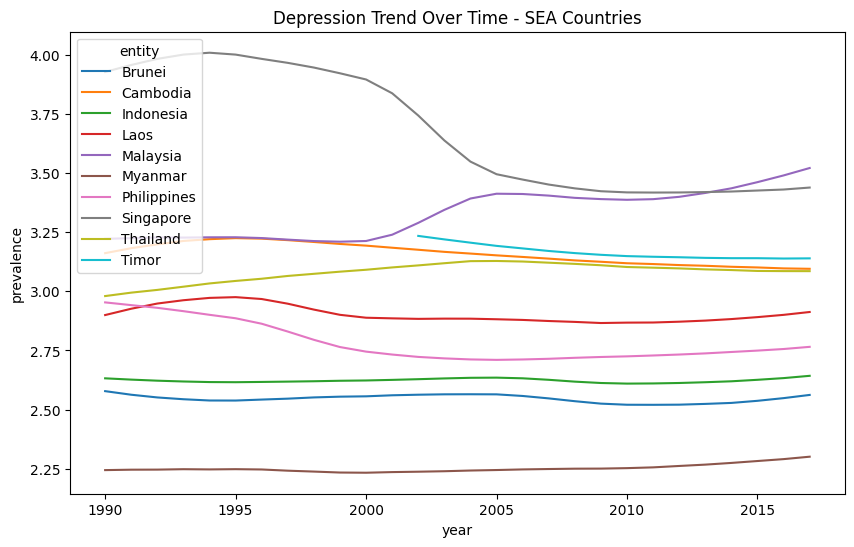

In [27]:
countries = ['Indonesia', 'Malaysia', 'Singapore', 'Brunei', 'Philippines', 'Myanmar', 'Thailand', 'Laos', 'Cambodia', 'Timor']
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'].isin(countries))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time - SEA Countries')
plt.show()

For Indonesia, the prevalence of depression is relatively stable from 1990 to 2017 at around 2.65%. Compared to that, the changes in Singapore and Malaysia, which are Indonesia's neighboring countries, are more prominent. Singapore starts with prevalence around 4%, which is the highest among SEA countries. There is then a steady decrease from 1994 until 2008, with the most significant decline in between 2001 and 2005. In then continue with steady number in 3.25%. On the other hand, Malaysia looks like the opposite of Singapore. It starts with a stable pervalence at 3.25% from 1990 until 2000, then the prevalance increase significantly to 3.4% in 2005. It continue with steady prevalance, until it began to increase in 2011 and continue to increase until the last scope of this data (2017) in 3.6%.

The following exploration will focus on the depression prevalence in Indonesia.

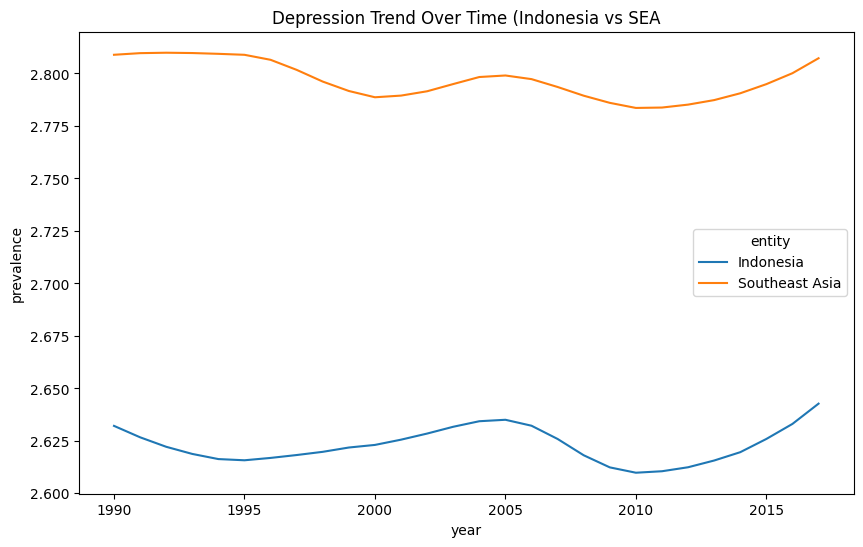

In [28]:
# Depression Trend
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'].isin(['Southeast Asia', 'Indonesia']))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time (Indonesia vs SEA')
plt.show()


Compared to the prevalence in Southeast Asia, the depression prevalance in Indonesia between 1990 and 2017 is always lower, which is around 2.625% compared to 2.8%. However, the pattern of changes over time is relatively similar, with a local peak in 2005 and increasing trend starting from 2010 to 2017 (the end of the scope). The difference is between 1996 and 2000, where SEA has a decrease while Indonesia continue the increase that started in 1995.

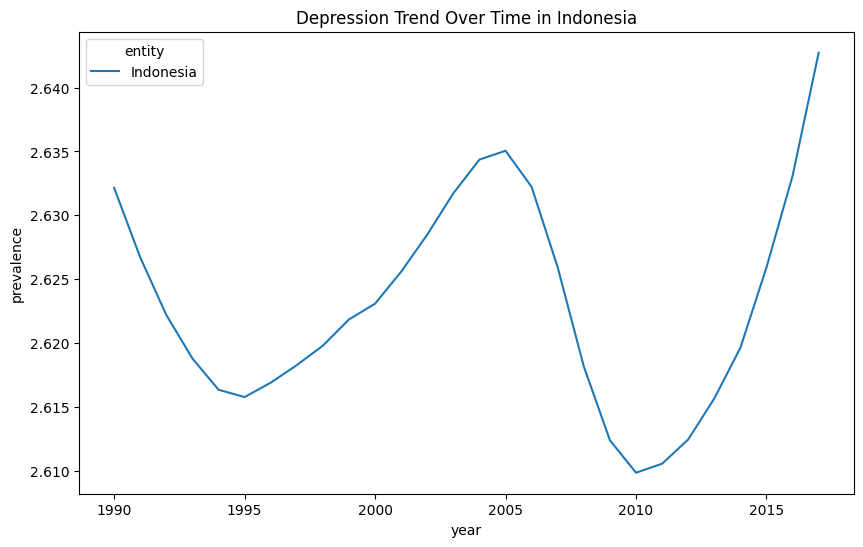

In [29]:
# Depression Trend
df_for_visual = df[(df['mental_disorder'] == 'depression') & (df['entity'] == 'Indonesia')]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_for_visual, x='year', y='prevalence', hue='entity')
plt.title('Depression Trend Over Time in Indonesia')
plt.show()


From the line chart above, we can see that there is a pattern of up and down in the prevalence of depression in Indonesia. In 1990, the prevalance is a little bit above 2.63%. It then decrese significantly until 2.615% in 1995. After that, there is persistent increase until 2005, where the prevalance reached 2.635%, higher than the number in 1990. Then it decrease to 2.61% in 2010, which is lower than in 1995. However, it took a sharp increase until exceeded 2.64% in 2017.

Indonesia had a population of 237,641,326 in 2010 and 261,355,500 in 2017. Based on the prevalance mentioned above, there were (2.61% * 237,641,326) = 6,202,438 Indonesians with depression in 2010 alone. Applying the same calculation, there were 6,899,785. This means there were 697,347 more people with depression in Indonesia in 2017 compared to 2010. And looking at the trend, it might be more in the following years.